In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Telco_churn.csv")

In [3]:
df.head()

,Unnamed: 0,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24,TenureGroup_24-48,TenureGroup_48-60,TenureGroup_60-72
0,0,0,1,29.85,29.85,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
1,1,0,34,56.95,1889.50,0,1,0,0,1,...,1,0,0,0,0,1,0,1,0,0
2,2,0,2,53.85,108.15,1,1,0,0,1,...,0,0,1,0,0,1,0,0,0,0
3,3,0,45,42.30,1840.75,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,4,0,2,70.70,151.65,1,0,0,0,1,...,0,0,1,0,1,0,0,0,0,0


In [4]:
df=df.drop("Unnamed: 0",axis=1)

In [5]:
X=df.drop("Churn",axis=1)  # Feature variables

In [6]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24,TenureGroup_24-48,TenureGroup_48-60,TenureGroup_60-72
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,1,0,0,0,0,1,0,1,0,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,1,1,1,1,0,1,...,1,0,1,0,0,1,1,0,0,0
7028,0,72,103.20,7362.90,0,1,1,1,0,1,...,1,0,1,1,0,0,0,0,0,1
7029,0,11,29.60,346.45,0,1,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0
7030,1,4,74.40,306.60,1,1,0,1,0,1,...,0,0,1,0,0,1,0,0,0,0


In [7]:
y=df["Churn"]   # Target variable
y

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int64

In [8]:
# Train test split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
X_train.shape

(5625, 34)

In [10]:
X_test.shape

(1407, 34)

In [11]:
y_train.value_counts()

0    4130
1    1495
Name: Churn, dtype: int64

In [12]:
y_test.value_counts()

0    1033
1     374
Name: Churn, dtype: int64

In [13]:
# A baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,precision_score,recall_score,confusion_matrix

lr=LogisticRegression(max_iter=500,random_state=42)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [14]:
# Churn recall = 54% 
# Indicating model is biased towards predicting non-churn

In [15]:
# Moving onto decision tree because of its ability to capture non linear relationships

from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=6,min_samples_split=15,min_samples_leaf=8,criterion='gini',random_state=42,class_weight='balanced')
dt.fit(X_train,y_train)
dt_pred=dt.predict(X_test)
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [16]:
# Churn Recall = 79%
# Indicating model is capturing more churn customers
# Non churn precision = 50%
# Indicating prediction of churn when customer wouldn't churn

In [17]:
# Data is highly imbalanced which is also a contributor to these results
# Performing SMOTE to balance the data

In [18]:
# Synthetic Minority Oversampling Technique

from imblearn.combine import SMOTEENN

smote=SMOTEENN(random_state=42)

In [19]:
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)

In [20]:
y_train_res.value_counts()

1    2464
0    2175
Name: Churn, dtype: int64

In [21]:
dt=DecisionTreeClassifier(max_depth=6,min_samples_split=15,min_samples_leaf=8,criterion='gini',random_state=42,class_weight='balanced')
dt.fit(X_train_res,y_train_res)
dt_pred=dt.predict(X_test)
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.89      0.73      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



In [22]:
# Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=200,criterion='gini',max_depth=7,min_samples_split=15,min_samples_leaf=7,random_state=42)

rf.fit(X_train_res,y_train_res)
rf_pred=rf.predict(X_test)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [23]:
# Recall of churn increased to 80% meaning model identifies 80% of customers who actually churn
# Precision of non churn to 91% indicating among all customers the model predicted as non-churn, 91% are actually non-churn 
# Despite, lesser precision of 51% for churn, it is an acceptable trade-off as missing a churner costs more than contacting a non-churner

In [24]:
cm=confusion_matrix(y_test,rf_pred)
cm

array([[738, 295],
       [ 73, 301]], dtype=int64)

<Figure size 432x360 with 0 Axes>

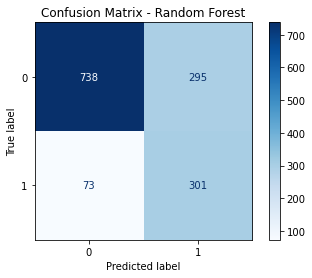

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["0","1"],
                           )
plt.figure(figsize=(6,5))
disp.plot(cmap="Blues",values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [27]:
# Feature Importance

feature_imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)
print(feature_imp.head(10))

tenure                             0.226022
TotalCharges                       0.083657
Contract_Two year                  0.079427
InternetService_Fiber optic        0.071902
TenureGroup_60-72                  0.051345
OnlineSecurity_Yes                 0.048392
MonthlyCharges                     0.043112
TechSupport_Yes                    0.042880
TechSupport_No internet service    0.041379
Contract_One year                  0.036648
dtype: float64


In [28]:
# Let's do risk segmentation obtained from the probability of churn of a customer 
y_prob=rf.predict_proba(X_test)[:,1]

In [29]:
def risk_segment(prob):
    if prob>= 0.7:
        return "High Risk"
    elif prob>=0.5:
        return "Medium Risk"
    elif prob>=0.2:
        return "Low Risk"
    else:
        return "Minimal Risk"

In [30]:
risk_segments=pd.Series(y_prob).apply(risk_segment)

In [31]:
risk_df=pd.DataFrame({"ActualChurn":y_test.values,"ChurnProbability":y_prob,"RiskSegment":risk_segments})

In [32]:
risk_df["RiskSegment"].value_counts(normalize=True)

Minimal Risk    0.425729
High Risk       0.297797
Low Risk        0.150675
Medium Risk     0.125800
Name: RiskSegment, dtype: float64

In [33]:
# Risk rates per band
ct=pd.crosstab(risk_df["RiskSegment"],risk_df["ActualChurn"],normalize="index")
ct=ct.reindex(["High Risk","Medium Risk","Low Risk","Minimal Risk"])
ct

ActualChurn,0,1
RiskSegment,,
High Risk,0.429594,0.570406
Medium Risk,0.649718,0.350282
Low Risk,0.834906,0.165094
Minimal Risk,0.936561,0.063439


In [34]:
# INSIGHTS

# 1.High Risk customers: More than half of customers in this segment churn. They should be prioritized for retention strategies
# 2.Medium Risk customers: A significant portion may still leave if there is no involvement. Engagemen strategies required
# 3.Low Risk customers: These require low intervention but still needs to be monitored periodically
# 4.Minimal Risk customers: Retention efforts can be focused less on this group while maintaining customer satisfaction

In [35]:
### KEY TAKEAWAYS

# 1.Churn Prediction:
# A churn prediction model was developed using Random Forest, achieving an overall accuracy of 74% with a recall of 80% for churn

# 2.Risk Segmentation:
# Risk segmentation based on predicted churn probability shows clear seperation
# High Risk: 56.4% churn rate
# Medium Risk: 36.21 churn rate
# Low Risk: 17.45 churn rate
# Minimal Risk: 6.01% churn rate

# 3.Business Insights:
# The segmentation allows businesses to prioritize retention strategies by focusing on high and medium risk customers

# 4.Future Advancements:
# Future work may include advanced hyperparameter tuning, customer clustering for behavioral segmentation,
# deployment as a churn prediction service.

# Overall, this project demonstrates how ML can be used to identify at-risk customers and support data-driven strategies